In [61]:
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import numpy as np

In [62]:
N_PEERS = 130
N_ITERS = 5
T_EVENT = 70

# TAGS = [f'{t_m}-300' for t_m in [0, 200, 400, 600]]
# TAGS.extend(
#     [f'300-{t_u}' for t_u in [100, 300, 500, 700]]
# )
TAGS = [f'{t_m}-300' for t_m in [0, 200, 400, 600]]
TAGS.extend(
    [f'300-{t_u}' for t_u in [100, 300, 500, 700]]
)

# DIR_PATHS = [f'../ablation/dev/t_min_{t_m}_unit_300/{N_PEERS}/' for t_m in [0, 200, 400, 600]]
# DIR_PATHS.extend(
#     [f'../ablation/dev/t_min_300_unit_{t_u}/{N_PEERS}/' for t_u in [100, 300, 500, 700]]
# )
DIR_PATHS = [f'../ablation/dev-v2/t_min_{t_m}_unit_300/{N_PEERS}/' for t_m in [0, 200, 400, 600]]
DIR_PATHS.extend(
    [f'../ablation/dev-v2/t_min_300_unit_{t_u}/{N_PEERS}/' for t_u in [100, 300, 500, 700]]
)

In [63]:
def parse_data():
    combined = []
    for dirpath in DIR_PATHS:
        result = []
        for i in range(N_ITERS):
            filepath = dirpath + f'r_{i}.txt'
            with open(filepath, 'r') as f:
                time_init = 0
                for line in f:
                    parts = line.strip().split()
                    if parts[1] == 'N/A':
                        continue
                    
                    time = int(parts[0])
                    if time_init == 0:
                        time_init = time

                    if time - time_init < 71_000: # 71 seconds.
                        continue
                        
                    reachability = float(parts[1])
                    if reachability > 0.99:
                        result.append((time - time_init)/1000 - T_EVENT)
                        break
                
        combined.append(result)
    return combined

In [64]:
def draw_dot_plot(
    data: list[list[float]],
    labels: list[str] = [str(v) for v in TAGS],
    title: str = "Dot Plot",
    dot_size: float = 20,
    color: str = "black",
    alpha: float = 0.5,
    jitter: float = 0.0,
    figsize: tuple = (10, 6),
):
    if labels is None:
        labels = [f"Group {i + 1}" for i in range(len(data))]

    if len(labels) != len(data):
        raise ValueError("`labels` length must match `data` length.")

    # Support per-group colors or a single color for all groups
    if isinstance(color, list):
        if len(color) != len(data):
            raise ValueError("`color` list length must match `data` length.")
        colors = color
    else:
        colors = [color] * len(data)

    fig, ax = plt.subplots(figsize=figsize)

    for col_idx, (group, label, c) in enumerate(zip(data, labels, colors)):
        x_positions = col_idx + 1 + np.random.uniform(-jitter, jitter, size=len(group))
        ax.scatter(x_positions, group, s=dot_size, color=c, alpha=alpha, zorder=3)

    # Styling
    ax.set_xticks(range(1, len(data) + 1))
    ax.set_xticklabels(labels)
    ax.set_xlim(0.5, len(data) + 0.5)
    ax.set_title(title, fontsize=14, fontweight="bold", pad=12)
    ax.set_ylabel("Time until r>99% (Sec)")
    ax.yaxis.grid(True, linestyle="--", alpha=0.5)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)

    plt.tight_layout()
    plt.show()

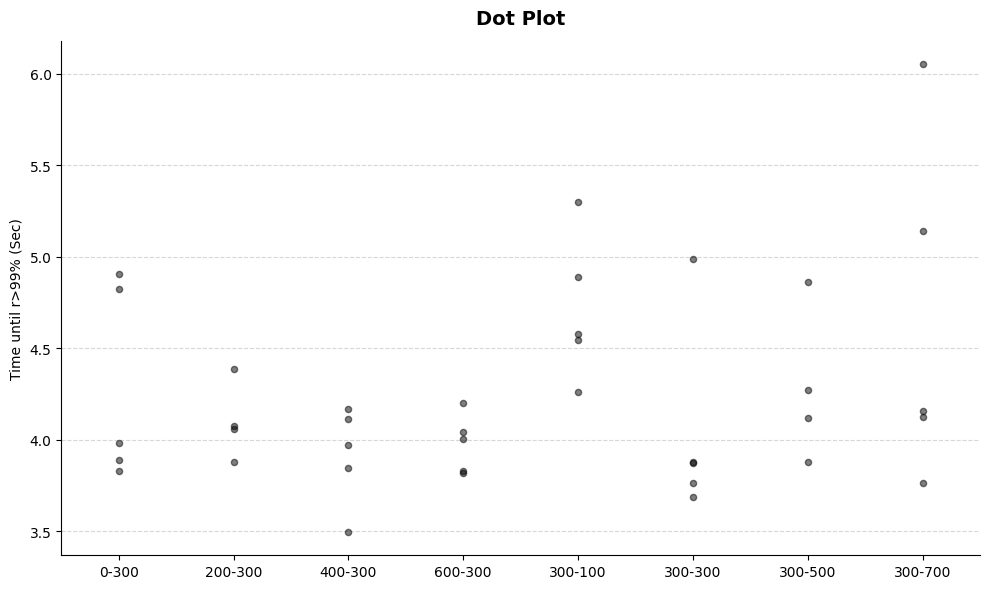

In [65]:
draw_dot_plot(parse_data())